# [Deep Agents - Backend](https://docs.langchain.com/oss/python/deepagents/backends)


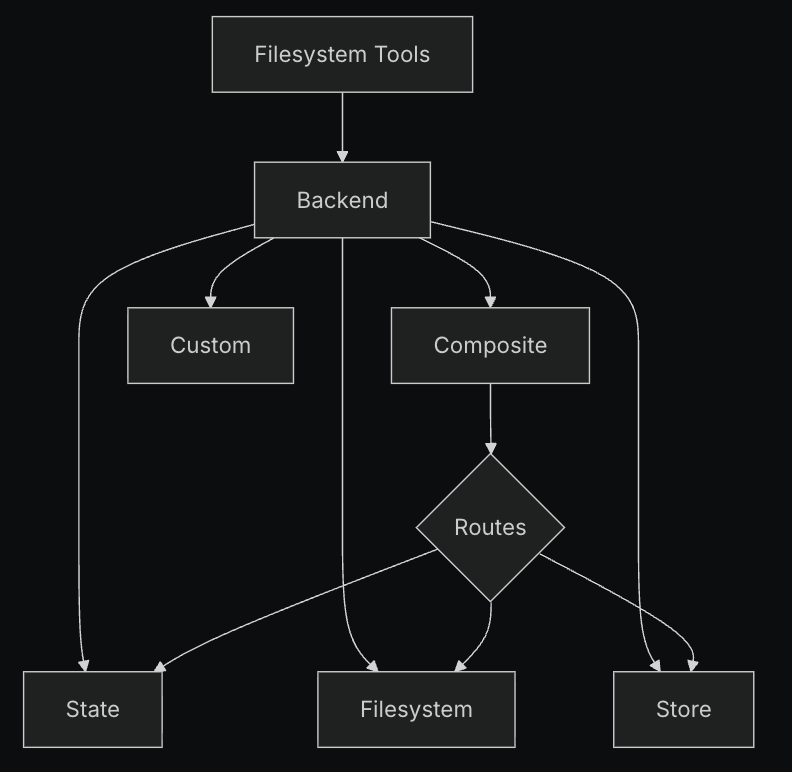

## 1. Backend란?

Deep Agents는 파일 시스템 인터페이스를 에이전트에게 제공합니다. 에이전트는 `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep` 같은 도구를 사용할 수 있습니다.

이러한 도구들은 **Backend**를 통해 작동하며, Backend는 플러그인 방식으로 교체 가능합니다.


### Backend의 역할
- 에이전트가 파일을 읽고 쓸 수 있는 공간 제공
- 임시 저장소(ephemeral) 또는 영구 저장소(persistent) 선택 가능
- 다양한 저장 방식 지원: 메모리, 로컬 디스크, Redis, 클라우드 스토리지 등


## 2. Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |


## 3. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

load_dotenv()


True

### LLM 정의


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### [PostgreSQL 구축](https://www.postgresql.org/)

PostgreSQL은 **확장성과 표준 SQL을 강력하게 지원하는 오픈소스 객체-관계형 데이터베이스 관리 시스템(DBMS)** 이다.

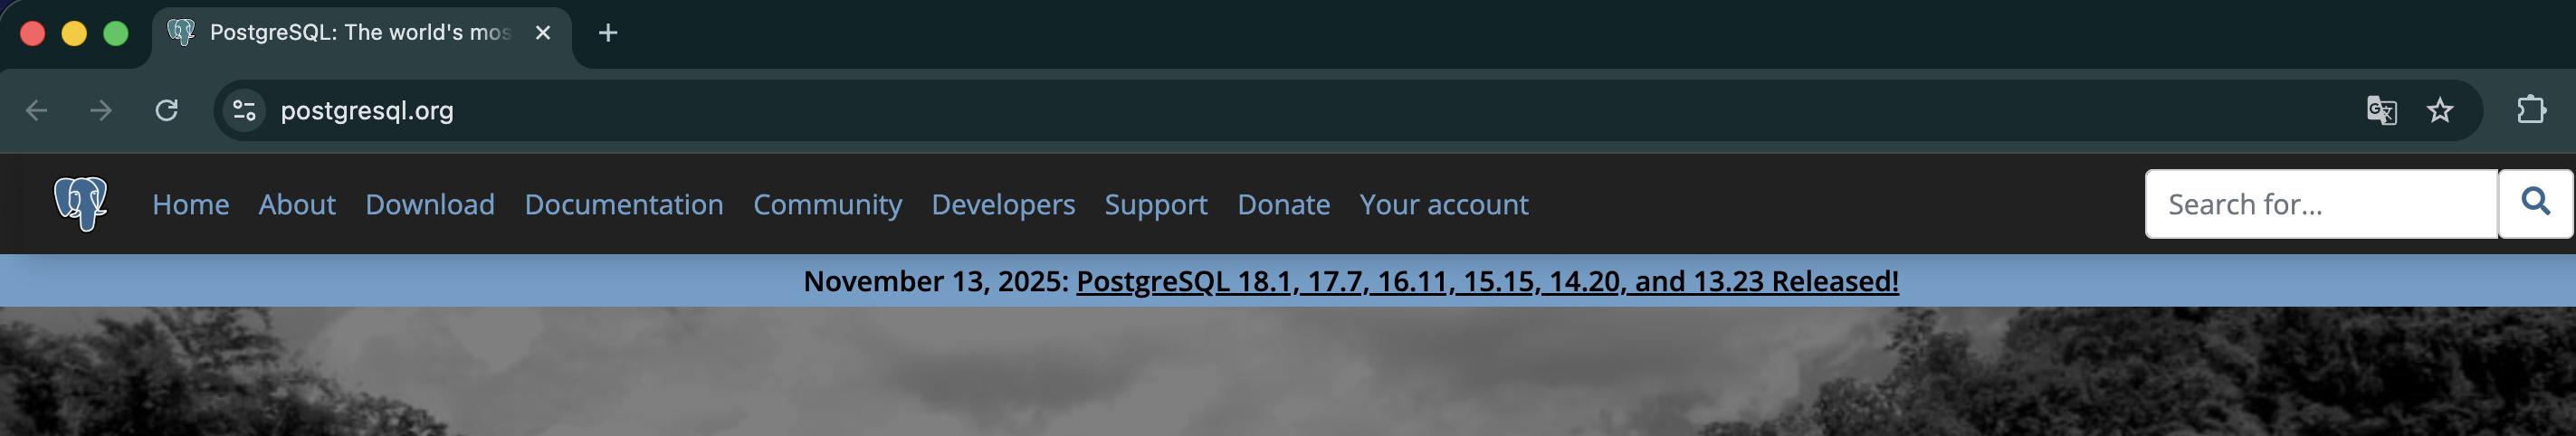

#### PostgreSQL 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd postgresql
docker-compose up -d
```

정상적으로 실행되었는지 확인:

```bash
docker ps
```

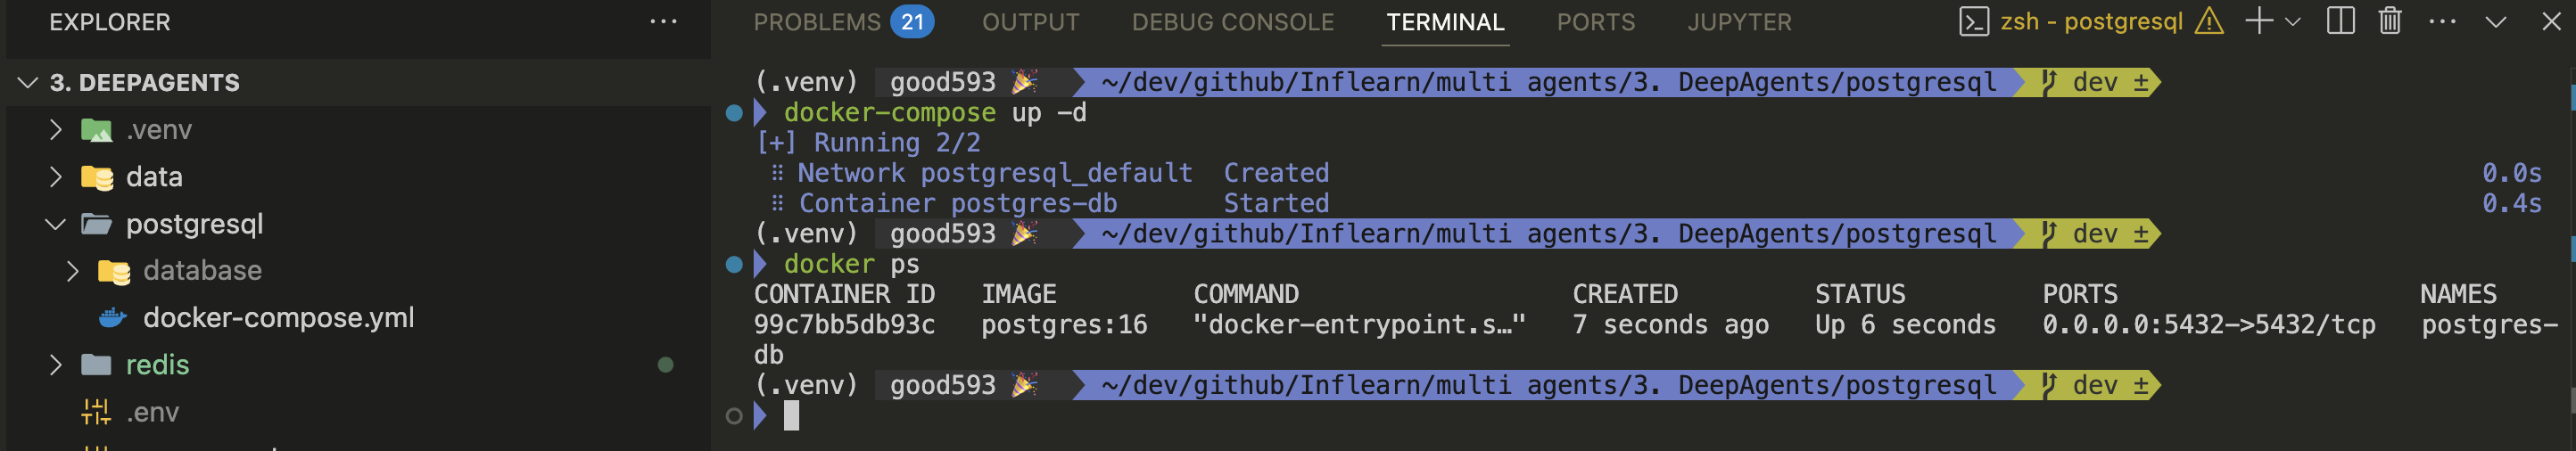

#### DBeaver 접속 

```sql
-- 현재 접속 중인 데이터베이스 확인
SELECT current_database();
```

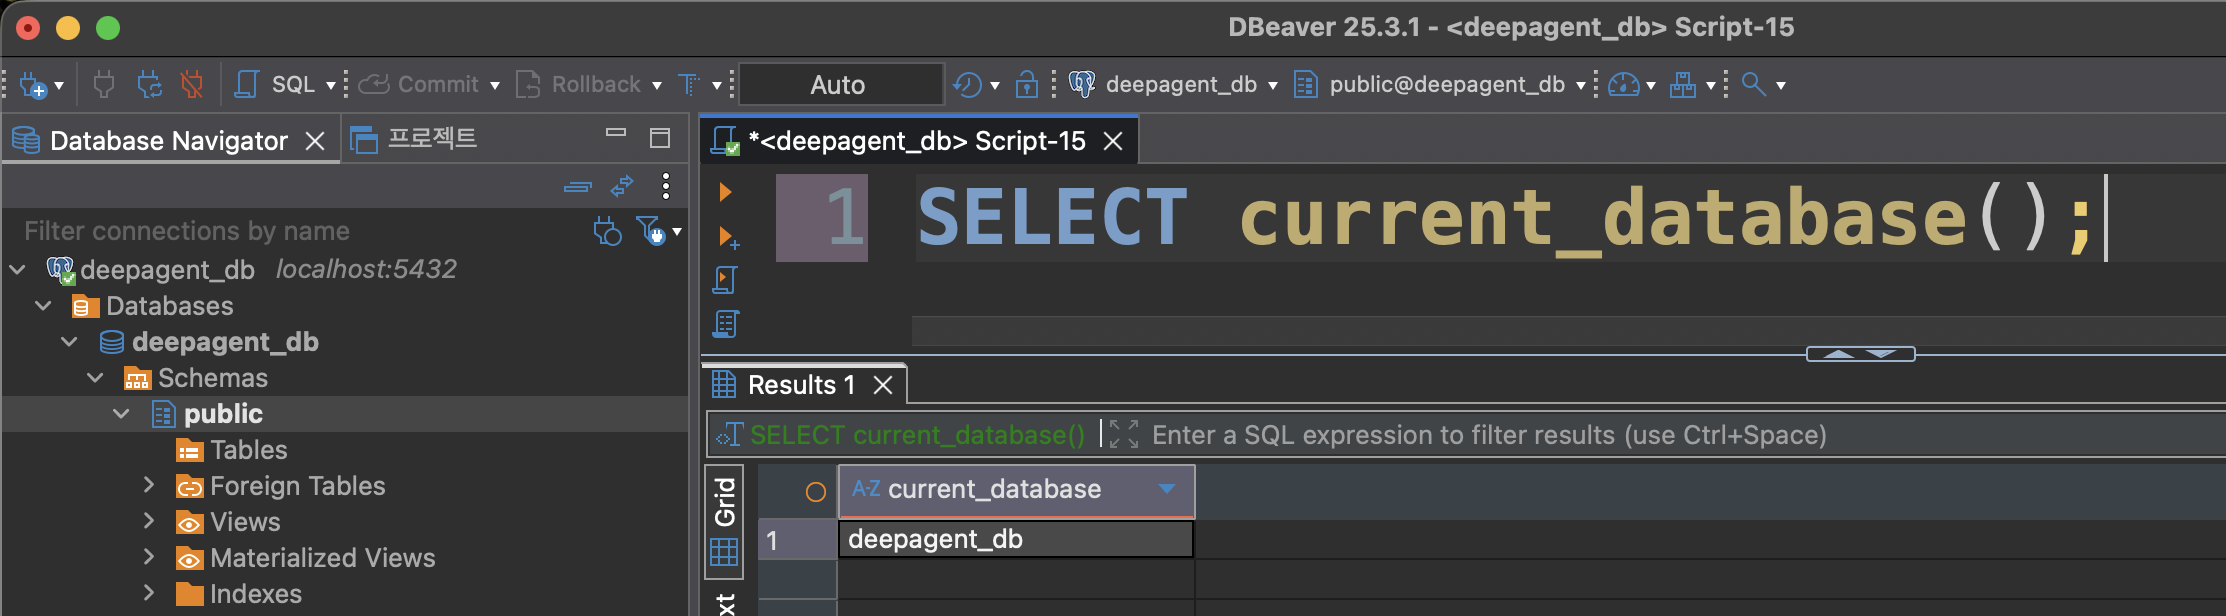

#### PostgreDB

In [3]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]

In [4]:
import psycopg

class PostgreDB(metaclass=Singleton):
    def __init__(self, DB_CONFIG:dict):
        # PostgreSQL 연결 설정
        DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

        self.conn = psycopg.connect(DB_URI, autocommit=True)

    def get_conn(self):
        return self.conn

In [5]:
# PostgreSQL 데이터베이스 접속을 위한 설정 정보 딕셔너리
DB_CONFIG = {
    # 1. 서버 주소: 데이터베이스가 설치된 서버의 IP나 도메인 (현재 본인 컴퓨터라면 localhost)
    "host": "localhost",
    # 2. 포트 번호: PostgreSQL의 기본 통신 포트는 5432입니다.
    "port": 5432,
    # 3. 데이터베이스 이름: 접속하려는 특정 DB의 명칭
    "database": "deepagent_db",
    # 4. 사용자 계정: DB에 접근 권한을 가진 ID
    "user": "admin",
    # 5. 비밀번호: 계정의 인증 암호
    # 주의: 코드에 직접 노출(Hard-coding)하면 보안에 취약하므로 .env 파일 등 환경변수 권장
    "password": "admin123"
}

In [6]:
# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1139738c0>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1139738c0>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


### [Redis 구축](https://redis.io/?utm_source=chatgpt.com)

Redis는 메모리 기반으로 동작하는 고성능 키-값(Key-Value) 구조의 오픈소스 데이터 저장소로, 캐시·세션·메시지 브로커 등에 널리 사용된다.


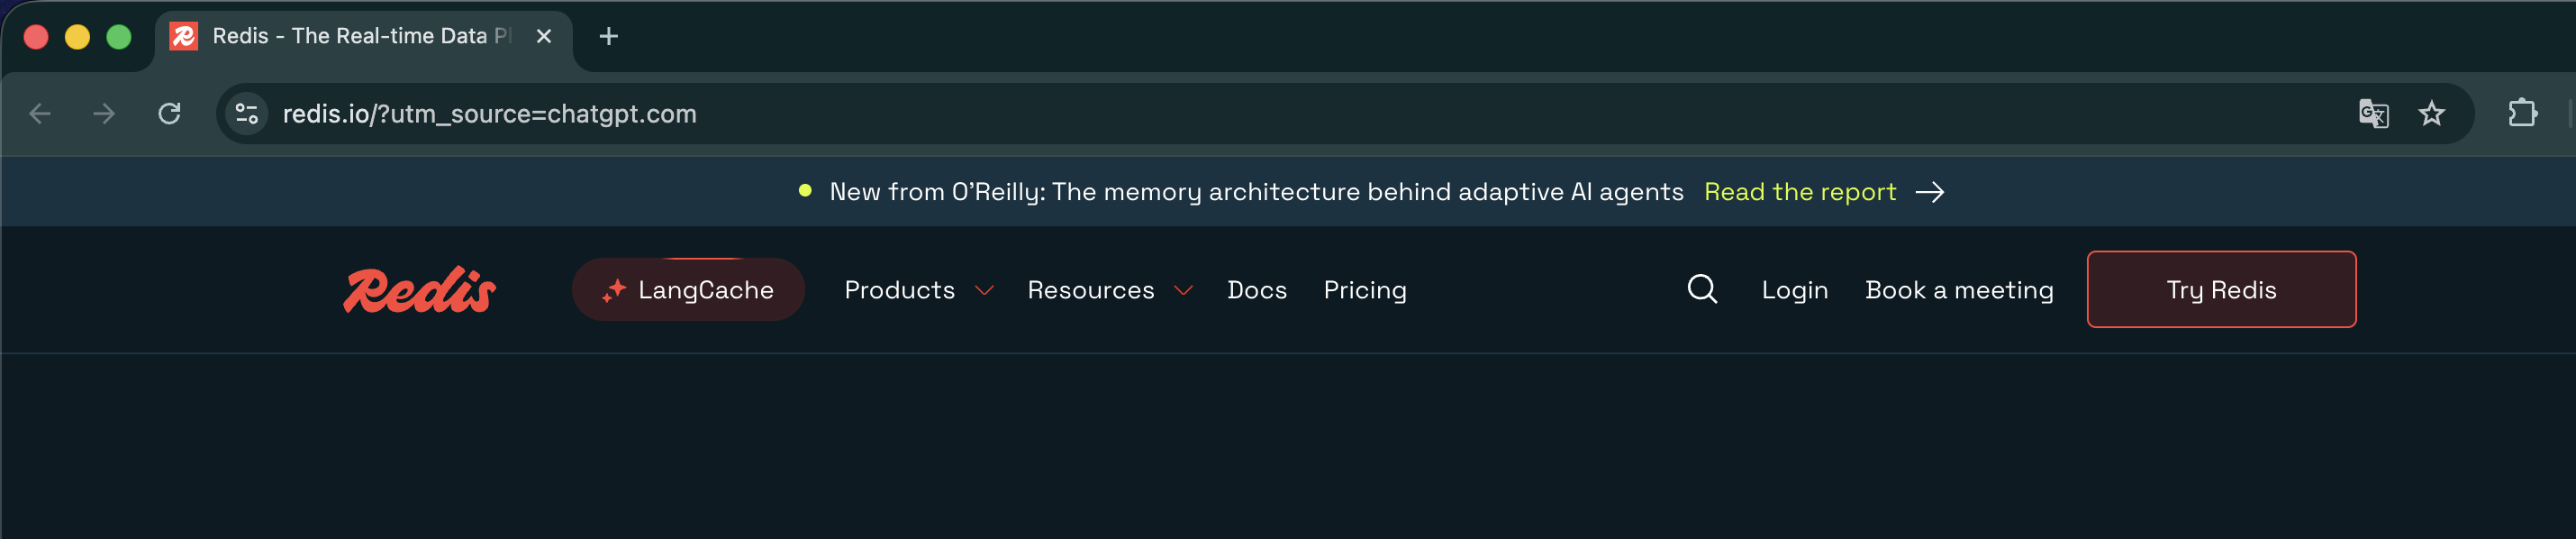

#### Redis 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd redis
docker-compose up -d
```

Redis가 정상적으로 실행되었는지 확인:

```bash
docker ps
```


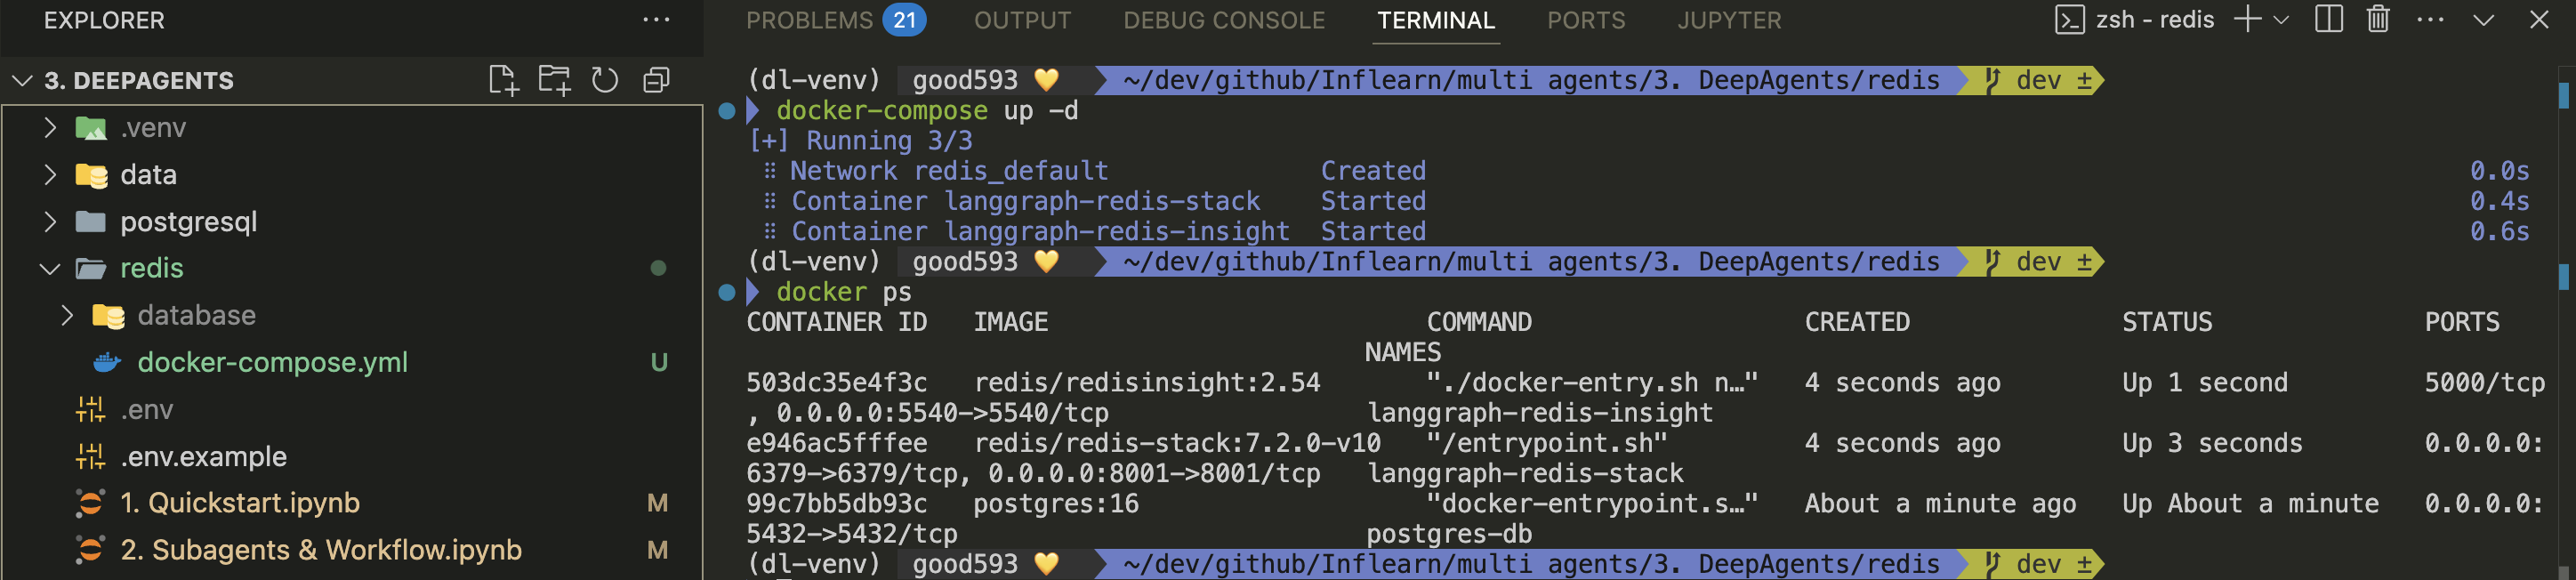

#### [RedisInsight 접속](http://localhost:8001/) 
```shell
http://localhost:8001/
```

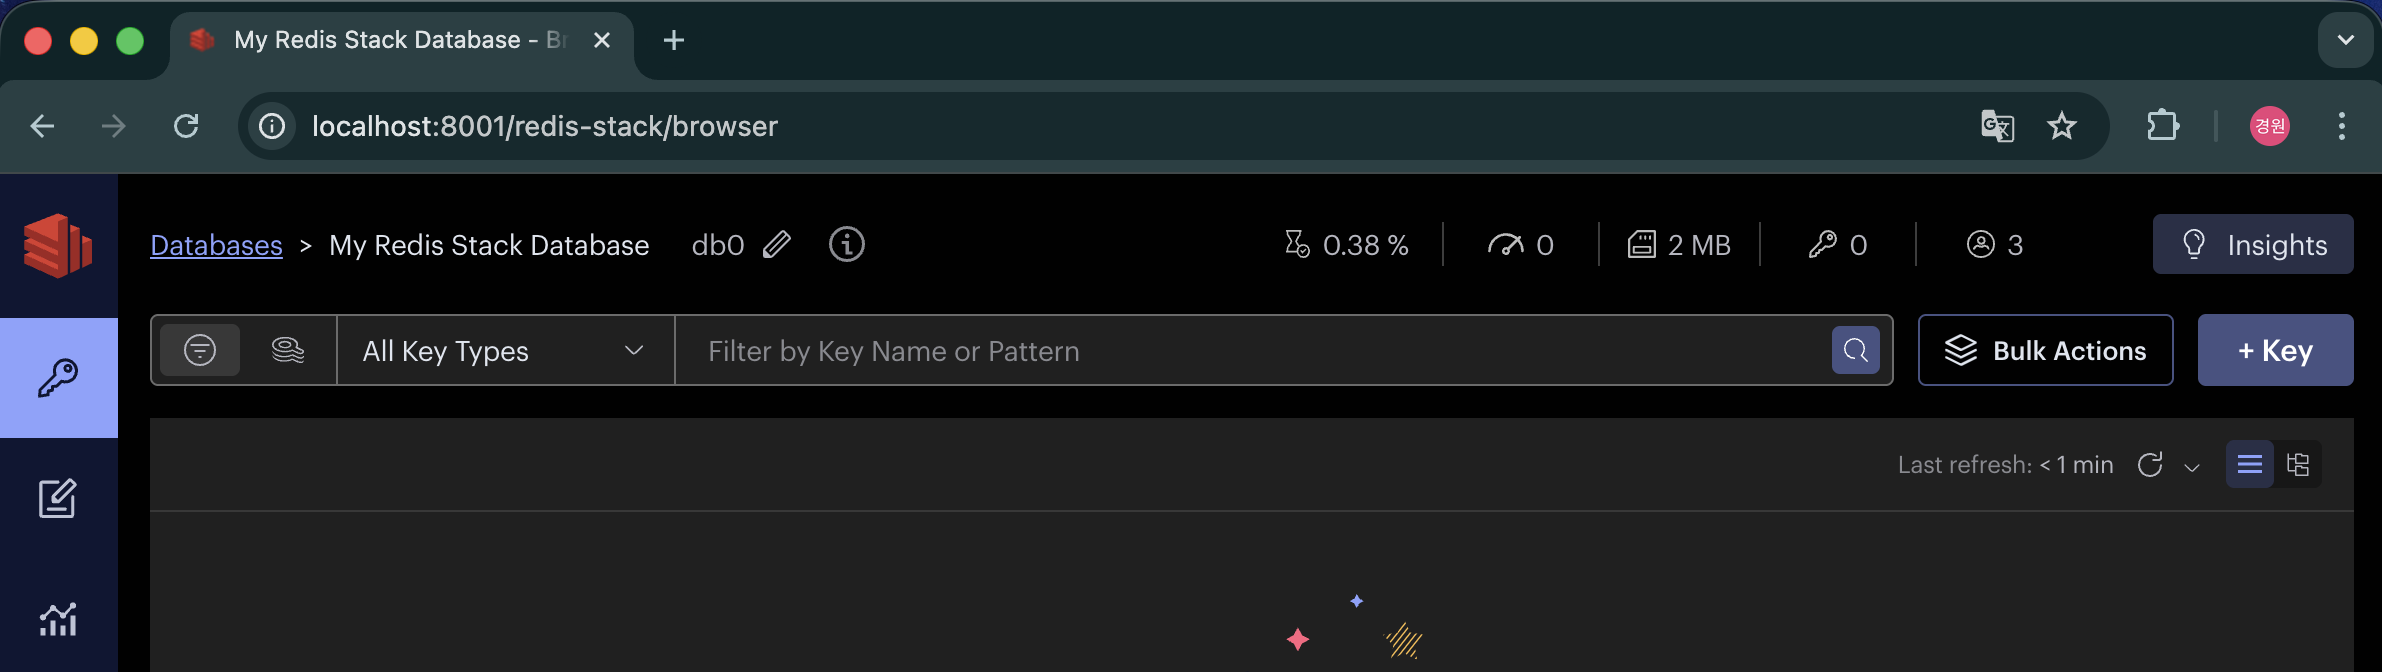

#### Redis Client

In [7]:
from redis import Redis
from langgraph.checkpoint.redis import RedisSaver

# 1. 클라이언트 생성 (명시적으로 protocol 3와 127.0.0.1 사용)
redis_client = Redis(
    host="127.0.0.1",   # Redis 서버 주소 (로컬 호스트)
    port=6379,          # Redis 기본 포트 번호
    db=0,               # 사용할 데이터베이스 번호 (기본값 0)
    decode_responses=True, # 응답 데이터를 바이트가 아닌 문자열(utf-8)로 자동 변환
    protocol=3          # Redis 직렬화 프로토콜(RESP3) 사용 (최신 성능 및 기능 최적화)
)


In [8]:
# 2. Redis 서버가 JSON 모듈을 지원하는지 직접 확인하는 코드 (Troubleshooting용)
try:
    modules = redis_client.execute_command("MODULE LIST")
    has_json = any(m.get('name') == b'ReJSON' or m.get('name') == 'ReJSON' for m in modules)
    if has_json:
        print("RedisJSON 모듈 확인 완료!")
    else:
        print("RedisJSON 모듈이 없습니다. 이미지를 확인하세요.")
except Exception as e:
    print(f"명령어 실행 실패: {e}")
    

RedisJSON 모듈 확인 완료!


## 4. StateBackend

`StateBackend`는 Deep Agents의 기본 백엔드입니다.


### 특징
- LangGraph의 State에 파일을 저장
- 체크포인트를 통해 동일 스레드 내에서는 여러 턴에 걸쳐 유지됨
- 스레드가 종료되면 데이터도 사라짐
- 에이전트의 스크래치 패드로 사용하기 적합


### Checkpointer (기본 - 임시 저장소) 

멀티 에이전트 그래프가 실행되다가 중단되거나, 다음 턴에서 이어서 실행할 수 있도록 모든 중간 상태(메모리, 메시지, 노드 진행 상황)를 자동 저장하는 저장 장치입니다.


> Redis vs PostgreSQL Checkpointer 비교

| 특징 | RedisSaver (Redis) | PostgresSaver (PostgreSQL) |
|------|-------------------|---------------------------|
| **속도** | 매우 빠름 (인메모리) | 상대적으로 느림 (디스크 I/O) |
| **데이터 지속성** | AOF/RDB로 백업 가능 | 완벽한 영구 저장 |
| **사용 사례** | 실시간 채팅, 빠른 응답 필요 | 장기 보관, 감사 추적 필요 |
| **복잡한 쿼리** | 제한적 | 강력한 SQL 지원 |
| **설정 난이도** | 간단 | 중간 (테이블 설정 필요) |

> 쉽게 비유하자면, AOF는 대화 내용을 모두 녹음하는 것이고, RDB는 대화 중 중요한 순간에 사진(스냅샷)을 찍는 것과 같습니다.

- AOF (Append Only File)
    - AOF는 Redis에서 발생하는 모든 쓰기 작업(Write Operations)을 로그 파일에 순차적으로 기록하는 방식입니다.
- RDB (Redis Database)
    - 특정 시점의 '결과(데이터 상태)'를 통째로 캡처하여 파일로 저장하는 방식입니다.


In [9]:
checkpointer = RedisSaver(redis_client=redis_client)

# 처음 실행 시 인덱스가 생성될 때까지 아주 짧은 시간이 걸릴 수 있습니다.
try:
    # 내부적으로 인덱스를 생성하도록 유도
    checkpointer.setup() 
    print("체크포인트 인덱스 설정 완료")
except Exception as e:
    print(f"인덱스 설정 중 참고사항: {e}")

체크포인트 인덱스 설정 완료


> 기본적으로 StateBackend가 사용됩니다

In [10]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,  # Redis checkpointer 사용
    system_prompt="""
    당신은 사용자에게 도움을 주는 어시스턴트입니다.
    """
)


### StateBackend 테스트

에이전트에게 파일을 생성하고 읽도록 요청해봅시다.


**자연어로 파일 시스템 조작하기**

1. **자연어 인터페이스**: Agent에게 자연어로 파일 작업을 요청할 수 있습니다
2. **가상 파일 시스템**: Deep Agent가 관리하는 내부 저장소를 사용합니다
3. **Thread 격리**: 각 thread_id는 독립적인 파일 시스템 공간을 가집니다
4. **주요 작업**:
   - 파일 생성 및 쓰기
   - 파일 읽기
   - 파일 목록 조회
   - 파일 수정 및 삭제
   - 디렉토리 생성 및 관리


In [11]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "state-backend-redis-test"}}

response = agent.invoke(
    {
        "messages": [
            HumanMessage(
                content="/workspace/notes.txt 파일을 만들고 'Redis Backend 테스트입니다'라고 작성해줘.")
        ]
    },
    config=config
)


In [12]:
print(response["messages"][-1].content)


완료되었습니다. /workspace/notes.txt 파일이 생성되었고, 내용은 다음과 같습니다:
Redis Backend 테스트입니다

다음에 내용 확인이나 수정/추가가 필요하시면 말씀해 주세요.


#### Redis Checkpointer에 저장된 대화 내용 확인 
- 같은 `thread_id`를 사용하면 이전에 생성한 파일에 접근할 수 있습니다
- 데이터는 Redis에 저장되므로 매우 빠르게 조회됩니다


In [13]:
# 같은 스레드에서 파일 읽기
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="이전에 생성했던 파일 내용을 읽어줘.")
        ]
    },
    config=config
)

print(response["messages"][-1].content)


다음과 같습니다:
Redis Backend 테스트입니다

필요하신 경우 수정이나 추가도 도와드릴게요.


> `thread_id`가 다른 경우에는 `이전 대화 내용을 알 수가 없기 때문에 답변을 하지 못함` 

In [14]:
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="이전에 생성했던 파일 내용을 읽어줘.")
        ]
    },
    # 새로운 thread_id 생성
    config={"configurable": {"thread_id": "new-state-backend-redis-test"}}
)

print(response["messages"][-1].content)

도와드리겠습니다! 다만 “이전에 생성했던 파일”이 어떤 파일인지 정확히 알려주실 수 있을까요?

원하시는 방식 선택해 주세요:
- 특정 파일 경로를 알려주기: 예) /home/user/generated.txt
- 제가 루트(/) 디렉토리에서 최근에 생성/수정된 파일 후보를 찾아 읽기: 확장자 필터를 주시면 그에 맞춰 읽어드리겠습니다. 예: .txt, .md, .json
- 특정 디렉토리에서 특정 확장자의 파일만 읽기: 예) /workspace/**/*.md

경로를 알려주시면 바로 읽어드리겠습니다.


#### Redis에 저장된 체크포인트 데이터 확인

> Redis CLI를 사용하여 실제로 저장된 데이터를 확인할 수 있습니다.


In [17]:
import redis

# Redis 연결
r = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)

# 저장된 키(thread_id) 확인
keys = r.keys("*state-backend-redis-test*")
print(f"✓ Redis에 저장된 키 개수: {len(keys)}")
print(f"✓ 키 목록 (처음 5개):")
for key in keys[:5]:
    print(f"  - {key}")


✓ Redis에 저장된 키 개수: 70
✓ 키 목록 (처음 5개):
  - write_keys_zset:state-backend-redis-test:__empty__:1f0f7d8a-9366-6d86-8002-d6a84d8b6c6a
  - checkpoint_write:state-backend-redis-test:__empty__:1f0f7d8c-de40-663e-8008-88b942dabcc7:3fd49a92-f21f-fa91-3929-325119a57463:1
  - write_keys_zset:state-backend-redis-test:__empty__:1f0f7d8c-de44-6c48-8009-49ea9825f176
  - write_keys_zset:state-backend-redis-test:__empty__:1f0f7d8a-9365-6076-8001-02e789003e28
  - checkpoint:new-state-backend-redis-test:__empty__:1f0f7d8e-364b-6b98-8002-fb4315a6e58b


> 저장된 내용 확인 

In [ ]:
import redis
import json

# Redis 연결
r = redis.Redis(host='localhost', port=6379, db=0, decode_responses=True)

pattern = "*state-backend-redis-test*"
keys = r.keys(pattern)

print(f"총 {len(keys)}개의 키를 상세 조회합니다.\n")
print(f"✓ 키 목록 (처음 5개) 내용 확인")
for key in keys[:5]:
    key_type = r.type(key)
    print(f"   Key: {key}")
    print(f"   Type: {key_type}")

    try:
        # 1. ReJSON-RL 타입 처리 (RedisJSON)
        if key_type == 'ReJSON-RL':
            # .json() 인터페이스를 사용하여 JSON 데이터 조회
            data = r.json().get(key)
            print(f"   Value (JSON): {json.dumps(data, indent=2, ensure_ascii=False)}")

        # 2. zset 타입 처리 (Sorted Set)
        elif key_type == 'zset':
            # 점수(score)와 함께 데이터 가져오기
            data = r.zrange(key, 0, -1, withscores=True)
            print(f"   Value (ZSet): {data}")

        # 3. 그 외 기본 타입들
        elif key_type == 'string':
            print(f"   Value: {r.get(key)}")
        elif key_type == 'hash':
            print(f"   Value: {r.hgetall(key)}")
            
    except Exception as e:
        print(f"조회 중 오류 발생: {e}")

    print("-" * 80)

총 70개의 키를 상세 조회합니다.

✓ 키 목록 (처음 5개) 내용 확인
   Key: write_keys_zset:state-backend-redis-test:__empty__:1f0f7d8a-9366-6d86-8002-d6a84d8b6c6a
   Type: zset
   Value (ZSet): [('checkpoint_write:state-backend-redis-test:__empty__:1f0f7d8a-9366-6d86-8002-d6a84d8b6c6a:0f2b9506-0b8a-86e9-a339-77b039eba371:0', 0.0), ('checkpoint_write:state-backend-redis-test:__empty__:1f0f7d8a-9366-6d86-8002-d6a84d8b6c6a:0f2b9506-0b8a-86e9-a339-77b039eba371:1', 1.0)]
--------------------------------------------------------------------------------
   Key: checkpoint_write:state-backend-redis-test:__empty__:1f0f7d8c-de40-663e-8008-88b942dabcc7:3fd49a92-f21f-fa91-3929-325119a57463:1
   Type: ReJSON-RL
   Value (JSON): {
  "thread_id": "state-backend-redis-test",
  "checkpoint_ns": "__empty__",
  "checkpoint_id": "1f0f7d8c-de40-663e-8008-88b942dabcc7",
  "task_id": "3fd49a92-f21f-fa91-3929-325119a57463",
  "task_path": "~__pregel_pull, PatchToolCallsMiddleware.before_agent",
  "idx": 1,
  "channel": "branch:to:Summ

#### [Redis Server 접속](http://localhost:8001/redis-stack/browser)

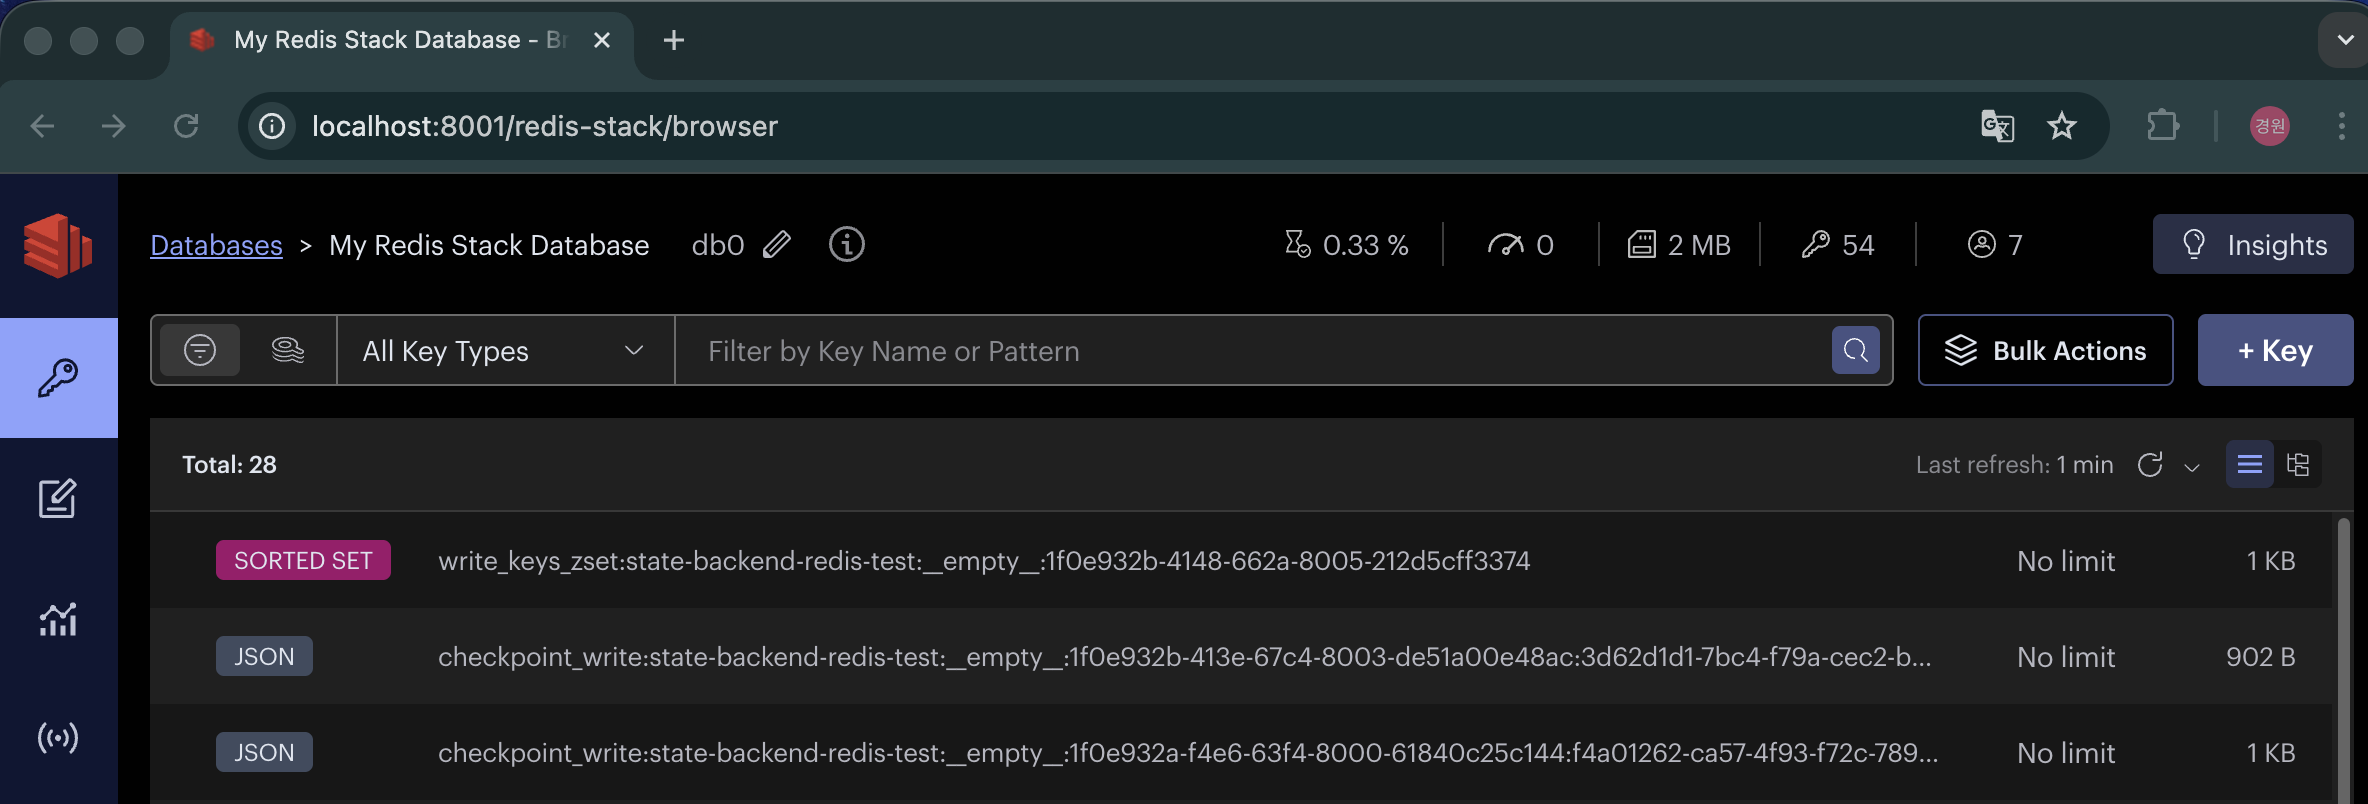

## 5. FilesystemBackend (로컬 디스크 저장)

`FilesystemBackend`는 실제 로컬 디스크에 파일을 읽고 쓸 수 있게 해줍니다.


In [20]:
import os
from pathlib import Path

# 임시 디렉토리 생성 (절대 경로로 변환)
temp_dir = Path("./temp").resolve()

# exist_ok=True → 폴더가 이미 있어도 에러 안냄
os.makedirs(temp_dir, exist_ok=True)

print("✓ 폴더 생성 완료:", temp_dir)


✓ 폴더 생성 완료: /Users/gyoungwon-cho/dev/github/Inflearn/multi agents/3. DeepAgents/temp


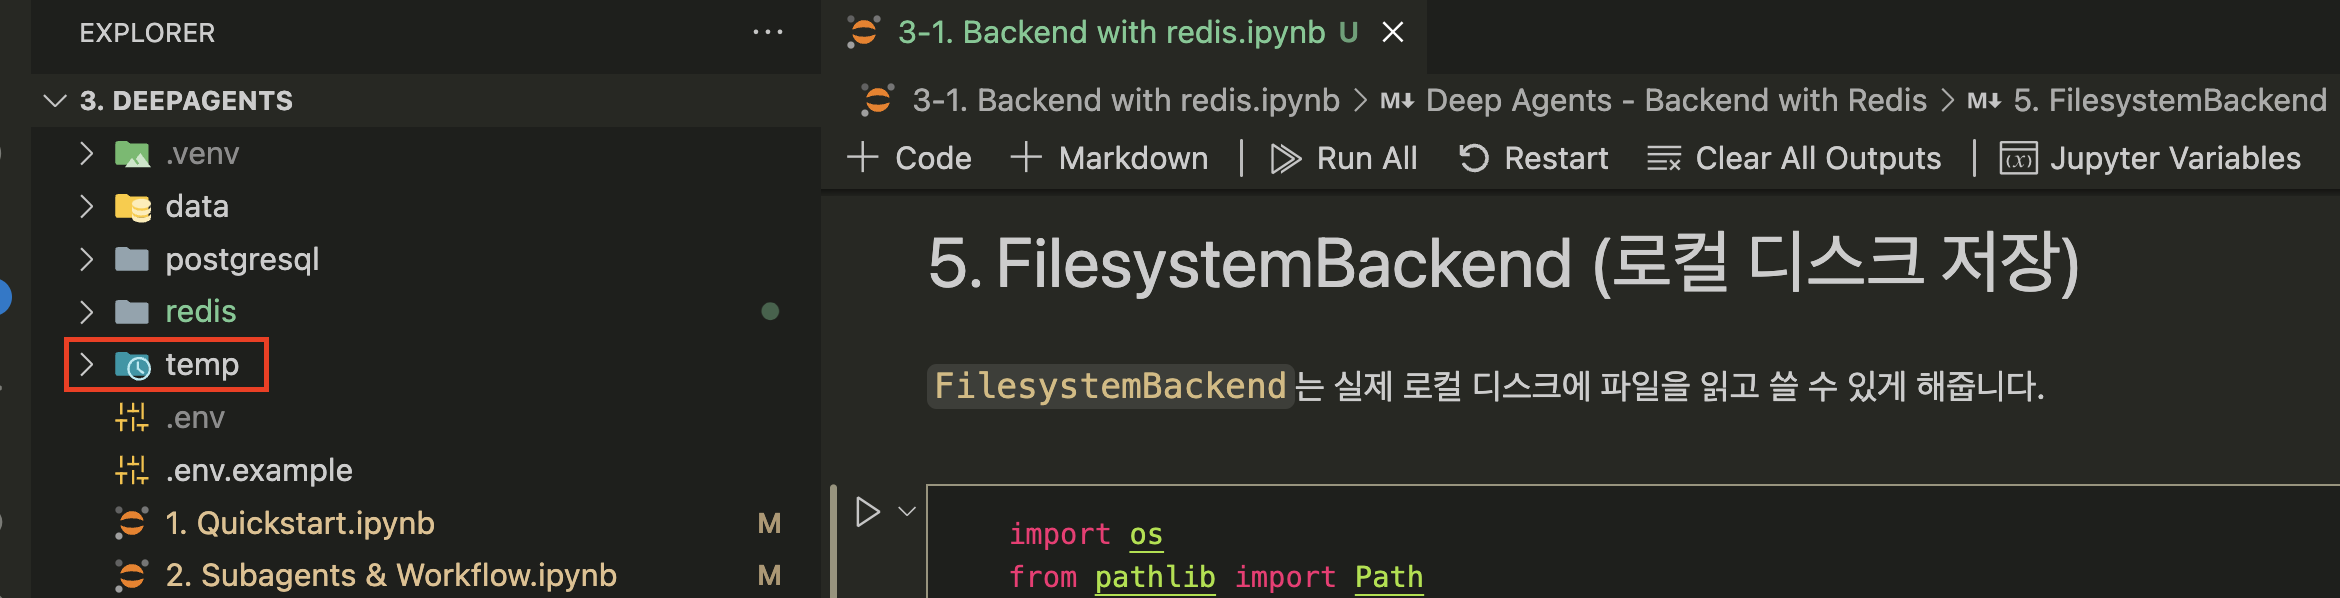

### 특징
- 설정한 `root_dir` 아래의 실제 파일 시스템에 접근
- 영구 저장 - 에이전트 재시작 후에도 유지
- `virtual_mode=True` 옵션으로 경로를 샌드박스화하고 정규화 가능
- 보안: 안전한 경로 해석, symlink traversal 방지


In [21]:
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

# FilesystemBackend 사용 (Redis checkpointer와 함께)
agent_fs = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,  # Redis checkpointer
    system_prompt="""
    당신은 사용자에게 도움을 주는 어시스턴트입니다.
    """,
    backend=FilesystemBackend(root_dir=temp_dir, virtual_mode=True)
)


### FilesystemBackend 테스트


In [22]:
from langchain.messages import HumanMessage

config_fs = {"configurable": {"thread_id": "filesystem-backend-redis-test"}}

response = agent_fs.invoke(
    {
        "messages": [
            HumanMessage(content="""
다음 작업을 수행해주세요:
1. /project/data.json 파일을 만들고 {"name": "redis-test", "value": 200} 내용을 작성
2. /project/readme.md 파일을 만들고 'Redis Backend와 Filesystem 통합 테스트' 내용을 작성
3. /project 디렉토리의 파일 목록을 보여주세요""")
        ]
    },
    config=config_fs
)

print(response["messages"][-1].content)


모든 작업을 완료했습니다.

있었던 내용 요약:
- /project/data.json 생성 및 내용 작성: {"name": "redis-test", "value": 200}
- /project/readme.md 생성 및 내용 작성: Redis Backend와 Filesystem 통합 테스트
- /project 디렉토리의 파일 목록:
  - /project/data.json
  - /project/readme.md

필요하신 경우 두 파일의 내용도 다시 확인하거나 수정/추가 파일 생성을 도와드릴게요.


#### 실제로 파일이 생성되었는지 확인


In [23]:
# 실제로 파일이 생성되었는지 확인
import os

print("✓ 생성된 파일들:")
for root, dirs, files in os.walk(temp_dir):
    for file in files:
        file_path = os.path.join(root, file)
        print(f"\n파일: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            print(f"내용: {f.read()}")


✓ 생성된 파일들:

파일: /Users/gyoungwon-cho/dev/github/Inflearn/multi agents/3. DeepAgents/temp/project/data.json
내용: {"name": "redis-test", "value": 200}

파일: /Users/gyoungwon-cho/dev/github/Inflearn/multi agents/3. DeepAgents/temp/project/readme.md
내용: Redis Backend와 Filesystem 통합 테스트


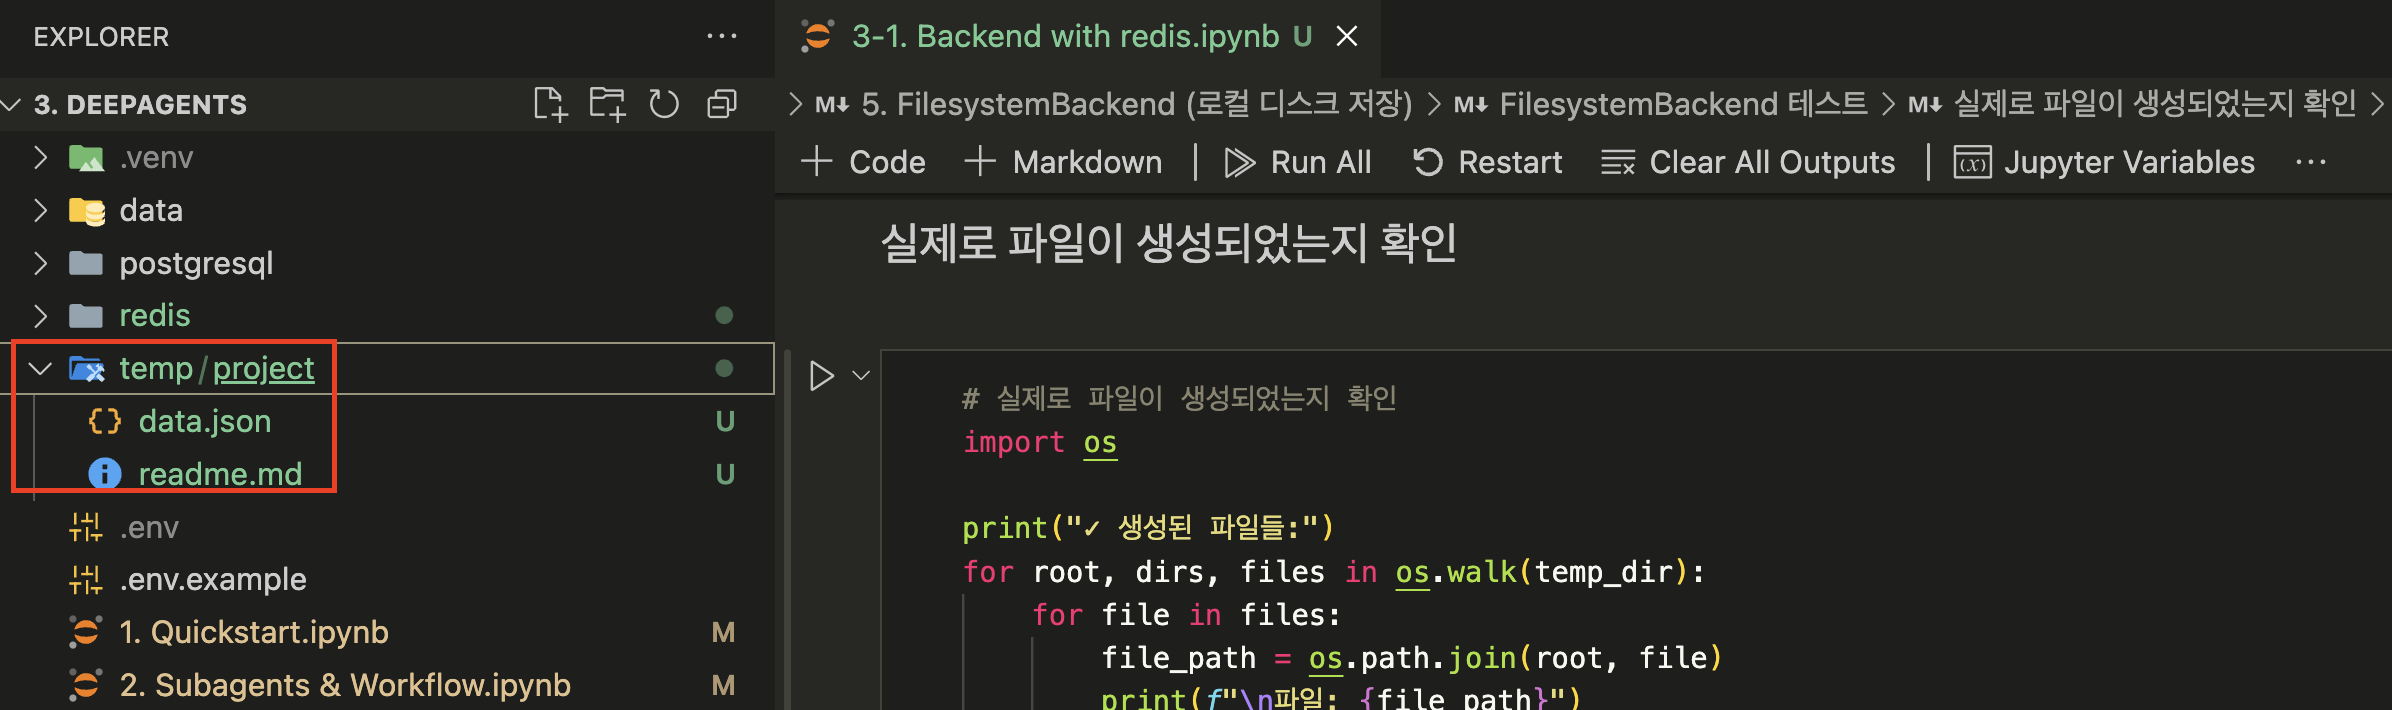

## 6. StoreBackend (장기 저장소)

`StoreBackend`는 LangGraph Store를 활용하여 여러 스레드 간에 데이터를 공유할 수 있습니다.

### 특징
- LangGraph `BaseStore`를 사용하여 파일 저장
- **여러 스레드 간 데이터 공유 가능** (가장 큰 차이점!)
- InMemoryStore, Redis Store 등 다양한 백엔드 지원
- 장기 메모리나 여러 세션에서 공유해야 하는 데이터에 적합


#### Store vs Checkpointer

| 구분 | Store | Checkpointer |
|------|-------------------|---------------------------|
| **주요 용도** | 특정 정보 저장 | 대화 내용 저장 |
| **저장 대상** | 사용자 프로필, 설정, 선호도 등 | 메시지 기록, 대화 흐름, 노드 상태 |
| **저장 방식** | 직접 저장/조회 (수동) | LangGraph가 자동 저장 |
| **데이터 예시** | 이름, 나이, 관심사, 좋아하는 색 | "안녕" → "반가워요" → "도와줘" |
| **테이블 이름** | `store` | `checkpoints`, `writes` |
| **데이터 수명** | 삭제 전까지 영구 보관 | 세션/스레드 단위로 관리 |
| **질문 예시** | "내 이름이 뭐야?" | "아까 뭐라고 했지?" |
| **코드 사용** | `store.put()`, `store.get()` | `config={"thread_id": "..."}` |
| **비유** | 메모장 (필요한 것만 기록) | 녹화기 (전체 대화 녹화) |
| **필수 여부** | 선택 (필요시 사용) | 대화 이어가기에 필수 |

### PostgreSQLStore 생성

In [24]:
from langgraph.store.postgres import PostgresStore

# PostgreSQLStore 생성
store = PostgresStore(
    conn=PostgreDB(DB_CONFIG).get_conn()
)
store.setup() # 필요한 테이블 자동 생성

| 테이블명      | 설명                                                                                                   |
| --------- | ---------------------------------------------------------------------------------------------------- |
| **store** | LangGraph의 key-value 데이터 저장을 위한 메인 스토리지 테이블. 에이전트 상태, 메타데이터, 일반 저장 데이터 등을 JSON/BYTE 형태로 저장하는 핵심 테이블. |
| **store_migrations** | PostgresStore 스키마 버전을 관리하는 마이그레이션 기록 테이블. `store.setup()` 실행 시 버전을 확인하여 필요한 스키마 업데이트를 관리. |

```sql
-- 테이블명 조회
select table_name FROM information_schema.tables 
WHERE table_schema = 'public';
```

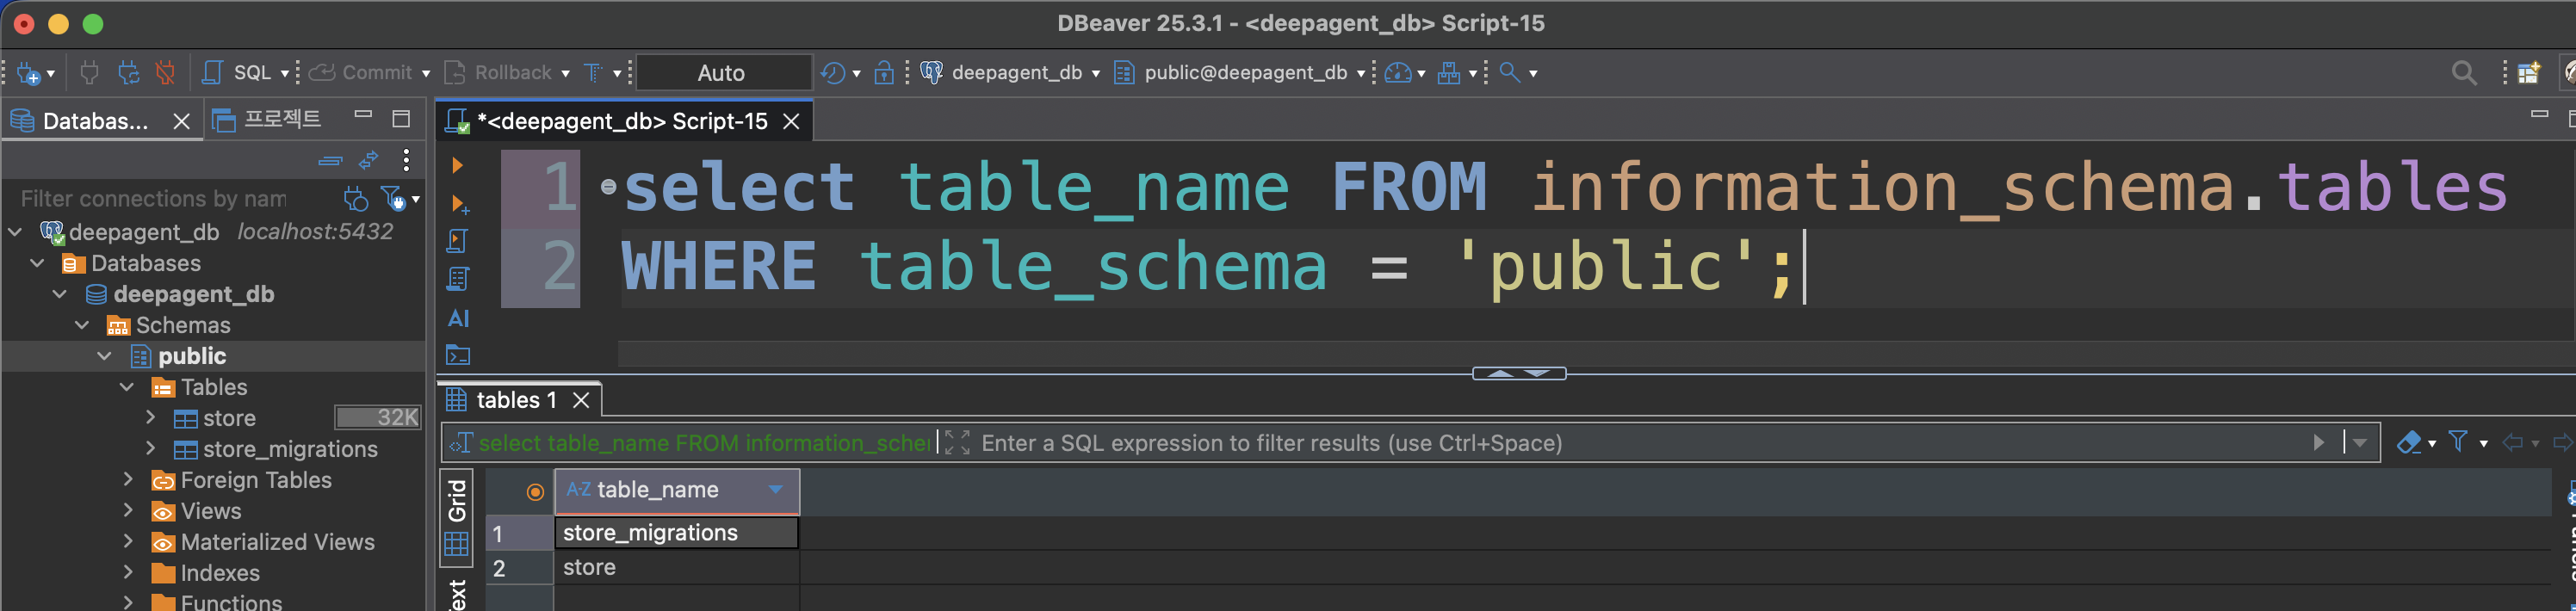

In [25]:
from deepagents.backends import StoreBackend

# StoreBackend 사용
agent_store = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,  # Redis checkpointer
    # backend: DeepAgent가 내부적으로 사용할 Runtime Backend를 지정.
    # StoreBackend는 Runtime(rt)을 받아서, rt.store 를 통해 데이터 저장/조회 기능을 제공.
    backend=(lambda rt: StoreBackend(rt)),
    # store: 에이전트의 메모리/상태를 저장하는 부분.
    store=store
)


### StoreBackend 테스트 - 스레드 1에서 파일 생성


In [26]:
config_thread1 = {"configurable": {"thread_id": "redis-thread-1"}}

response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "/shared/user_preferences.txt 파일을 만들고 '사용자 선호 언어: 한국어, Backend: Redis'라고 저장해줘."
            }
        ]
    },
    config=config_thread1
)

print(response["messages"][-1].content)


파일이 생성되어 내용을 저장했습니다.

경로: /shared/user_preferences.txt
내용:
사용자 선호 언어: 한국어, Backend: Redis


```sql
-- 저장된 데이터 조회 
select * from store;
```

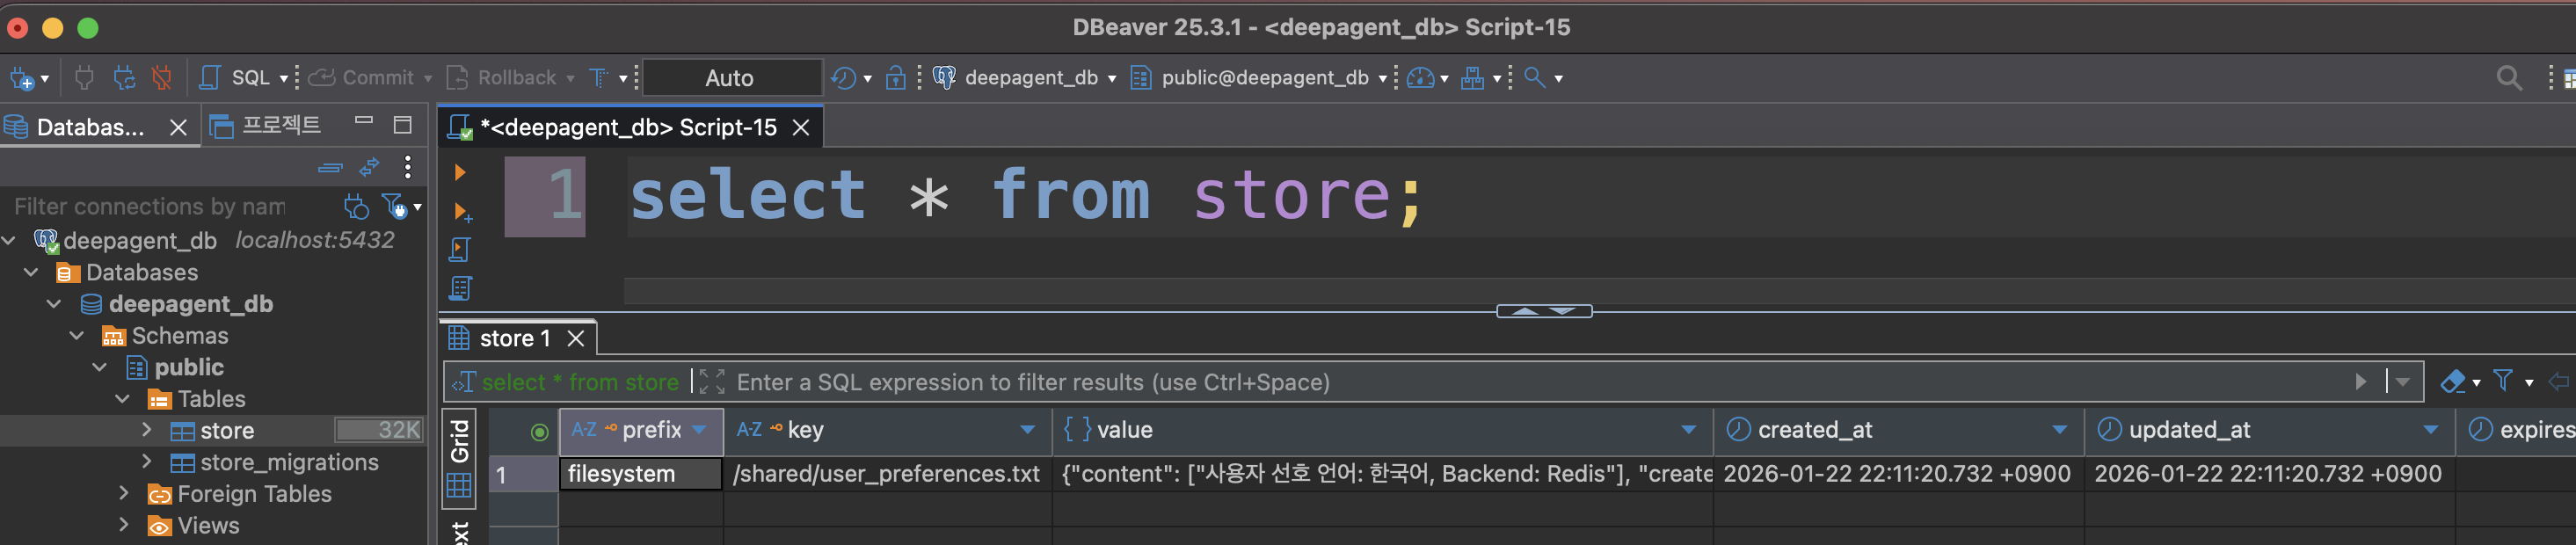

### Checkpointer 테스트 

> Checkpointer를 적용했기 때문에 이전 대화내용을 기억하고 답변할 수 있습니다.


In [27]:
response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "이전에 생성했던 파일 내용을 읽어줘."
            }
        ]
    },
    config=config_thread1  # 동일한 thread_id 사용!!
)

print(response["messages"][-1].content)
print("\n✓ Redis Checkpointer 덕분에 이전 대화 맥락을 기억합니다!")


경로: /shared/user_preferences.txt
내용:
사용자 선호 언어: 한국어, Backend: Redis

✓ Redis Checkpointer 덕분에 이전 대화 맥락을 기억합니다!


### Store 테스트 

> `Store`에 저장을 한다면, `thread_id`가 다르더라도 `store의 데이터`를 조회해서 답변을 할 수 있습니다.


In [28]:
config_thread2 = {"configurable": {"thread_id": "redis-thread-2"}}  # 다른 스레드!

response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "/shared/user_preferences.txt 파일을 읽어줘."
            }
        ]
    },
    config=config_thread2
)

print(response["messages"][-1].content)
print("\n✓ 다른 스레드(redis-thread-2)에서도 redis-thread-1이 만든 파일을 읽을 수 있습니다!")


다음과 같이 읽었습니다:
- 내용: 사용자 선호 언어: 한국어, Backend: Redis

✓ 다른 스레드(redis-thread-2)에서도 redis-thread-1이 만든 파일을 읽을 수 있습니다!


## [7. Langsmith](https://smith.langchain.com/)

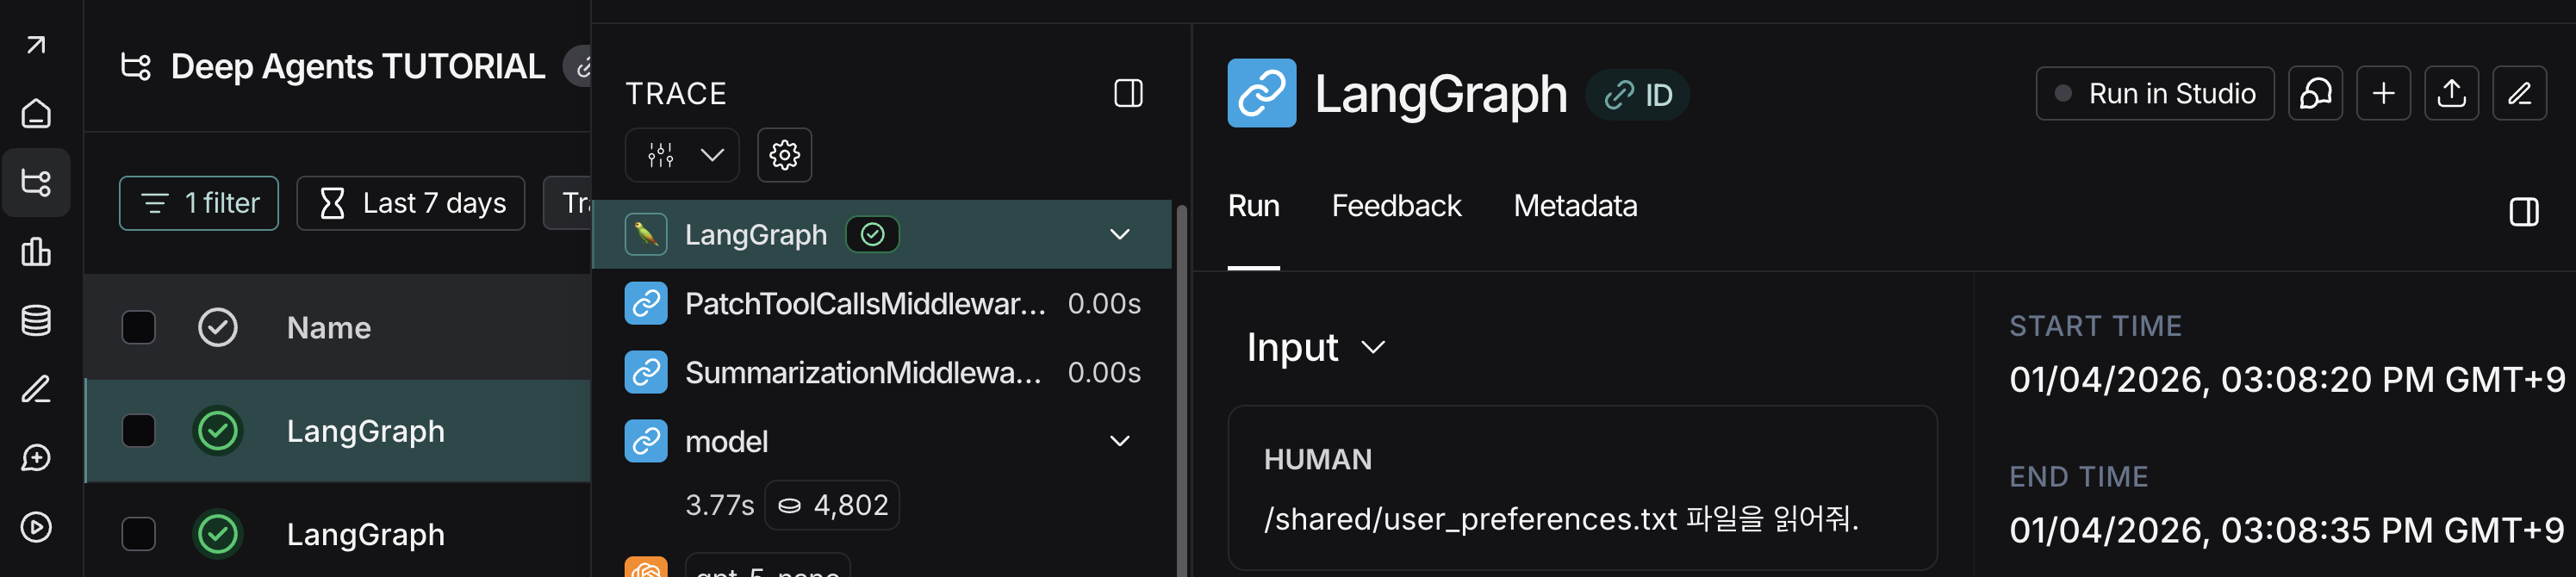